In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('../datasets/AmesHousing.csv')

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
(df.isnull().mean()*100)[df.isnull().sum()>0]

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [7]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
(X_train.isnull().mean()*100)[X_train.isnull().sum()>0]

Lot Frontage      16.766212
Alley             93.088737
Mas Vnr Type      60.836177
Mas Vnr Area       0.810580
Bsmt Qual          2.602389
Bsmt Cond          2.602389
Bsmt Exposure      2.687713
BsmtFin Type 1     2.602389
BsmtFin SF 1       0.042662
BsmtFin Type 2     2.645051
BsmtFin SF 2       0.042662
Bsmt Unf SF        0.042662
Total Bsmt SF      0.042662
Bsmt Full Bath     0.042662
Bsmt Half Bath     0.042662
Fireplace Qu      48.805461
Garage Type        5.119454
Garage Yr Blt      5.204778
Garage Finish      5.204778
Garage Cars        0.042662
Garage Area        0.042662
Garage Qual        5.204778
Garage Cond        5.204778
Pool QC           99.488055
Fence             79.948805
Misc Feature      95.989761
dtype: float64

In [10]:
X_train['Garage Yr Blt'].isnull().mean()*100

np.float64(5.2047781569965865)

In [11]:
X_train['Garage Yr Blt'].info()

<class 'pandas.core.series.Series'>
Index: 2344 entries, 381 to 860
Series name: Garage Yr Blt
Non-Null Count  Dtype  
--------------  -----  
2222 non-null   float64
dtypes: float64(1)
memory usage: 36.6 KB


In [12]:
X_train['Garage Yr Blt'].sample(5)

390     1974.0
1718    2005.0
2670       NaN
1319    1982.0
2223    1960.0
Name: Garage Yr Blt, dtype: float64

In [13]:
mean_Garage_Yr_Blt = X_train['Garage Yr Blt'].mean()
median_Garage_Yr_Blt = X_train['Garage Yr Blt'].median()

In [14]:
X_train['Garage Yr Blt mean'] = X_train['Garage Yr Blt'].fillna(mean_Garage_Yr_Blt)
X_train['Garage Yr Blt median'] = X_train['Garage Yr Blt'].fillna(median_Garage_Yr_Blt)

In [15]:
X_train[['Garage Yr Blt','Garage Yr Blt median','Garage Yr Blt mean']].sample(5)

,Garage Yr Blt,Garage Yr Blt median,Garage Yr Blt mean
1733,2005.0,2005.0,2005.0
266,1997.0,1997.0,1997.0
2449,1995.0,1995.0,1995.0
654,1958.0,1958.0,1958.0
2402,2004.0,2004.0,2004.0


In [16]:
#Variance is the spread of values.
print('Original Garage Yr Blt variable variance:', X_train['Garage Yr Blt'].var())
print('Garage Yr Blt variable variance after median imputation:', X_train['Garage Yr Blt median'].var())
print('Garage Yr Blt variable variance after mean imputation:', X_train['Garage Yr Blt mean'].var())

Original Garage Yr Blt variable variance: 659.416710266254
Garage Yr Blt variable variance after median imputation: 625.0987559705112
Garage Yr Blt variable variance after mean imputation: 625.0808849771021


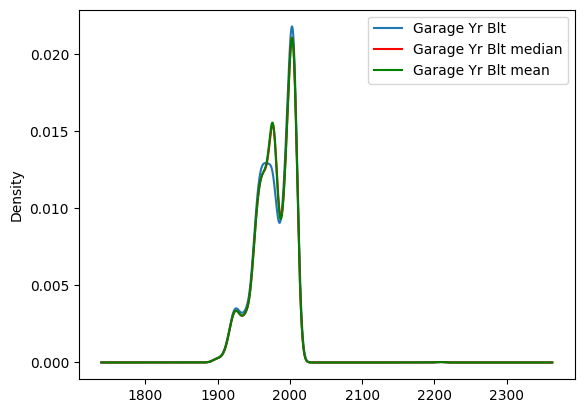

In [17]:
fig = plt.figure()
#Here above, we are creating a object of class matplotlib.figure.Figure
ax = fig.add_subplot(111)
#Here we are calling the function add_subplot in the above class using its object, this function return axes attribute
#Axes are basically all the graph are defined by x-axis,y-axis,plotted area. A Figure can contain multiple axes
X_train['Garage Yr Blt'].plot(kind='kde',ax=ax)
X_train['Garage Yr Blt median'].plot(kind='kde',ax=ax, color='red')
X_train['Garage Yr Blt mean'].plot(kind='kde',ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')
#Not writing everything about the above two lines but basicaly first line gets the lines(plotted data) and labels from the plot and the second line sets it as the legend for the particular axis.

In [18]:
X_train.cov(numeric_only=True)

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Garage Yr Blt mean,Garage Yr Blt median
Order,7.106191e+05,2.581566e+10,9.185721e+02,-2.250761e+02,2.015111e+05,-6.316521e+01,-1.605904e+01,-1.273458e+03,-1.305340e+03,-6.645707e+03,...,1.911516e+03,1.596255e+03,-5.355049e+02,3.728680e+02,1.784020e+03,-4.324261e+03,3.120204e+02,-1.082011e+03,-8.998658e+02,-8.976059e+02
PID,2.581566e+10,3.560417e+16,3.603224e+07,-3.909285e+08,4.434272e+10,-6.667703e+07,2.065209e+07,-1.928336e+09,-5.627456e+08,-7.581868e+09,...,-7.622084e+08,2.150225e+09,-7.641430e+07,-1.938977e+08,1.781157e+07,-1.172844e+09,-2.243306e+07,5.055669e+06,-1.137305e+09,-1.133539e+09
MS SubClass,9.185721e+02,3.603224e+07,1.832059e+03,-4.188815e+02,-6.540438e+04,3.615659e+00,-3.117004e+00,5.838159e+01,4.870812e+01,1.546521e+02,...,4.795679e+00,-6.765824e+01,-4.256605e+01,-1.296801e+02,-6.889781e+00,-8.781787e+02,2.200713e-01,-1.818114e+00,9.900490e+01,9.965037e+01
Lot Frontage,-2.250761e+02,-3.909285e+08,-4.188815e+02,5.484036e+02,7.508787e+04,6.368377e+00,-2.019384e+00,7.713868e+01,3.361180e+01,7.571314e+02,...,2.576177e+02,1.708218e+01,2.795520e+01,1.062943e+02,1.803797e+02,6.062016e+02,4.072489e-01,-1.347028e-02,3.269836e+01,3.239496e+01
Lot Area,2.015111e+05,4.434272e+10,-6.540438e+04,7.508787e+04,6.481712e+07,9.751906e+02,-3.036806e+02,5.236467e+03,9.154543e+02,1.604682e+05,...,4.767681e+04,1.440375e+04,4.091501e+03,2.769123e+04,3.148583e+04,3.738762e+05,2.031548e+02,-2.298163e+02,-1.648009e+03,-1.719803e+03
Overall Qual,-6.316521e+01,-6.667703e+07,3.615659e+00,6.368377e+00,9.751906e+02,1.927987e+00,-1.442034e-01,2.433780e+01,1.585554e+01,1.023959e+02,...,2.659684e+01,-1.303222e+01,6.232010e-01,4.199084e+00,1.787026e+00,6.083094e+00,3.803083e-02,-2.262658e-02,1.835806e+01,1.831290e+01
Overall Cond,-1.605904e+01,2.065209e+07,-3.117004e+00,-2.019384e+00,-3.036806e+02,-1.442034e-01,1.222481e+00,-1.274576e+01,1.133659e+00,-2.856919e+01,...,-5.591170e+00,5.394376e+00,1.055197e+00,2.589003e+00,-7.541147e-01,2.513655e+01,-4.254194e-03,5.330743e-02,-8.552007e+00,-8.557398e+00
Year Built,-1.273458e+03,-1.928336e+09,5.838159e+01,7.713868e+01,5.236467e+03,2.433780e+01,-1.274576e+01,9.206026e+02,3.745923e+02,1.629115e+03,...,3.626103e+02,-7.701367e+02,1.375405e+01,-5.621134e+01,3.701526e+00,-2.115174e+02,-3.510267e-01,-5.429862e-01,5.947172e+02,5.938795e+02
Year Remod/Add,-1.305340e+03,-5.627456e+08,4.870812e+01,3.361180e+01,9.154543e+02,1.585554e+01,1.133659e+00,3.745923e+02,4.320697e+02,6.419997e+02,...,2.904196e+02,-3.055732e+02,1.841301e+01,-4.252717e+01,-8.317834e+00,-4.896891e+01,2.642194e-01,9.139003e-01,3.189650e+02,3.186325e+02
Mas Vnr Area,-6.645707e+03,-7.581868e+09,1.546521e+02,7.571314e+02,1.604682e+05,1.023959e+02,-2.856919e+01,1.629115e+03,6.419997e+02,2.966631e+04,...,1.760299e+03,-1.479023e+03,9.994732e+01,6.665770e+02,2.736323e+01,6.010102e+03,-3.580007e-01,-7.588307e-01,1.036555e+03,1.033979e+03


In [19]:
X_train.corr(numeric_only=True)

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Garage Yr Blt mean,Garage Yr Blt median
Order,1.000000,0.162298,0.025458,-0.011381,0.029692,-0.053964,-0.017230,-0.049789,-0.074495,-0.045710,...,0.033328,0.028249,-0.025903,0.007924,0.055222,-0.008229,0.136663,-0.975998,-0.042696,-0.042589
PID,0.162298,1.000000,0.004461,-0.088477,0.029190,-0.254492,0.098990,-0.336819,-0.143478,-0.233278,...,-0.059371,0.170004,-0.016513,-0.018409,0.002463,-0.009971,-0.043896,0.020373,-0.241078,-0.240277
MS SubClass,0.025458,0.004461,1.000000,-0.409800,-0.189798,0.060837,-0.065864,0.044954,0.054746,0.020931,...,0.001647,-0.023582,-0.040550,-0.054276,-0.004200,-0.032913,0.001898,-0.032299,0.092516,0.093118
Lot Frontage,-0.011381,-0.088477,-0.409800,1.000000,0.472802,0.191379,-0.078714,0.104217,0.067479,0.189991,...,0.160324,0.010830,0.049890,0.080330,0.199813,0.047264,0.006402,-0.000437,0.053702,0.053202
Lot Area,0.029692,0.029190,-0.189798,0.472802,1.000000,0.087235,-0.034115,0.021437,0.005470,0.115504,...,0.087039,0.026690,0.020722,0.061617,0.102046,0.074496,0.009317,-0.021706,-0.008187,-0.008544
Overall Qual,-0.053964,-0.254492,0.060837,0.191379,0.087235,1.000000,-0.093930,0.577688,0.549354,0.428606,...,0.281533,-0.140020,0.018301,0.054176,0.033582,0.007028,0.010113,-0.012391,0.528819,0.527510
Overall Cond,-0.017230,0.098990,-0.065864,-0.078714,-0.034115,-0.093930,1.000000,-0.379934,0.049327,-0.149740,...,-0.074325,0.072785,0.038915,0.041948,-0.017797,0.036470,-0.001421,0.036661,-0.309370,-0.309561
Year Built,-0.049789,-0.336819,0.044954,0.104217,0.021437,0.577688,-0.379934,1.000000,0.593944,0.312021,...,0.175653,-0.378666,0.018484,-0.033189,0.003183,-0.011183,-0.004272,-0.013608,0.783982,0.782867
Year Remod/Add,-0.074495,-0.143478,0.054746,0.067479,0.005470,0.549354,0.049327,0.593944,1.000000,0.179319,...,0.205353,-0.219312,0.036120,-0.036652,-0.010441,-0.003779,0.004693,0.033432,0.613759,0.613111
Mas Vnr Area,-0.045710,-0.233278,0.020931,0.189991,0.115504,0.428606,-0.149740,0.312021,0.179319,1.000000,...,0.150543,-0.128023,0.023566,0.069072,0.004129,0.055750,-0.000769,-0.003345,0.245291,0.244674


<Axes: >

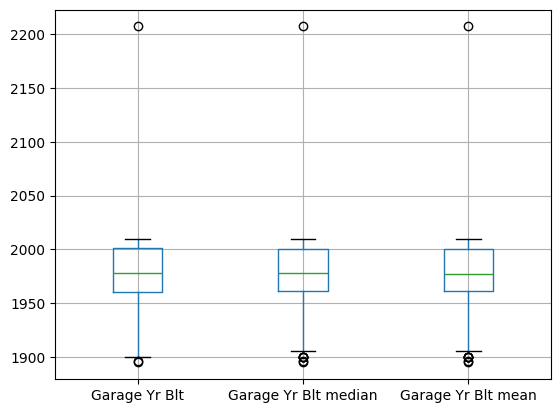

In [20]:
X_train[['Garage Yr Blt','Garage Yr Blt median','Garage Yr Blt mean']].boxplot()
#Filling the missing values did not change the distribution much

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
im1 = SimpleImputer(strategy='mean')
im2 = SimpleImputer(strategy='median')

In [23]:
trf = ColumnTransformer([
    ('mean',im1,['Garage Yr Blt']),
    ('median',im2,['Garage Yr Blt'])
], remainder='passthrough')

In [24]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mean', ...), ('median', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_nam

In [25]:
trf.named_transformers_

{'mean': SimpleImputer(),
 'median': SimpleImputer(strategy='median'),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [26]:
trf.named_transformers_['mean'].statistics_
#Found the mean and below median

array([1977.95426009])

In [27]:
trf.named_transformers_['median'].statistics_

array([1979.])

In [28]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)
#Transforming i.e. imputing the mean and median. It will create two different columns for the Garage Yr Blt, one with mean imputed and other with median imputed, In numpy form

In [ ]:
X_train[:,0]
#This is the numpy array. First column in im1 i.e. mean-imputed Garage Yr Blt

array([1968.0, 1954.0, 1977.0, ..., 1984.0, 1961.0, 1960.0],
      shape=(2344,), dtype=object)

In [34]:
X_train[:,1]

array([1968.0, 1954.0, 1977.0, ..., 1984.0, 1961.0, 1960.0],
      shape=(2344,), dtype=object)